# ENEM 2025: primeiro a participação, depois as notas

Esta leitura acompanha **4.810.772 registros divulgados de RESULTADOS 2025**. Vamos entender quem chegou a cada dia, o que mudou entre eles e como se distribuem as notas de quem participou.

A apresentação lê os agregados já validados. Não reconstrói a trusted nem atualiza CSVs ou relatórios. Para executar, use o ambiente do projeto; cópias externas preservam as saídas para leitura, mas dependem do projeto para execução.

In [1]:
from pathlib import Path
import sys
import json
import hashlib
import pandas as pd
from IPython.display import display, Image

raiz = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/participacao_graficos.py").is_file())
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))
from src.participacao_graficos import gerar_graficos_participacao, numero, porcentagem, NOMES

def conferir_hash(caminho, esperado):
    with caminho.open("rb") as arquivo:
        obtido = hashlib.file_digest(arquivo, "sha256").hexdigest()
    if obtido != esperado:
        raise ValueError(f"Arquivo diverge da auditoria: {caminho.name}")

auditoria_participacao = json.loads((raiz / "reports/validacao_participacao_2025.json").read_text(encoding="utf-8"))
auditoria_notas = json.loads((raiz / "reports/validacao_desempenho_2025.json").read_text(encoding="utf-8"))
conferir_hash(raiz / "trusted/resultados_2025_base.parquet", auditoria_participacao["sha256_depois"])
assert auditoria_participacao["sha256_depois"] == auditoria_notas["sha256_fonte_depois"]
for nome, esperado in auditoria_participacao["hashes_csv"].items():
    conferir_hash(raiz / "analitica" / nome, esperado)
conferir_hash(raiz / "analitica/desempenho_2025.csv", auditoria_notas["sha256_indicadores_csv"])
participacao = auditoria_participacao["resultado"]
resumo_dias = participacao["resumo"]
assert (resumo_dias["total_base"], resumo_dias["presentes_dia1"], resumo_dias["presentes_dia2"], resumo_dias["presentes_ambos"]) == (4810772, 3457555, 3260336, 3244348)
tabela = pd.read_csv(raiz / "analitica/desempenho_2025.csv")
figuras_participacao = gerar_graficos_participacao(participacao, raiz / "apresentacao/graficos")

## O 2º dia teve 197.219 presenças completas a menos que o 1º.

No **1º dia (LC + CH)**, foram **3.457.555 presenças completas — 71,87% da base**. No **2º dia (CN + MT)**, foram **3.260.336 — 67,77%**.

**Achado desta base:** não houve presença isolada em uma das duas áreas do mesmo dia; os pares concordam em todos os registros. Isso foi conferido nos dados, não é uma regra universal. “Presença completa” significa presença nas duas áreas do dia.

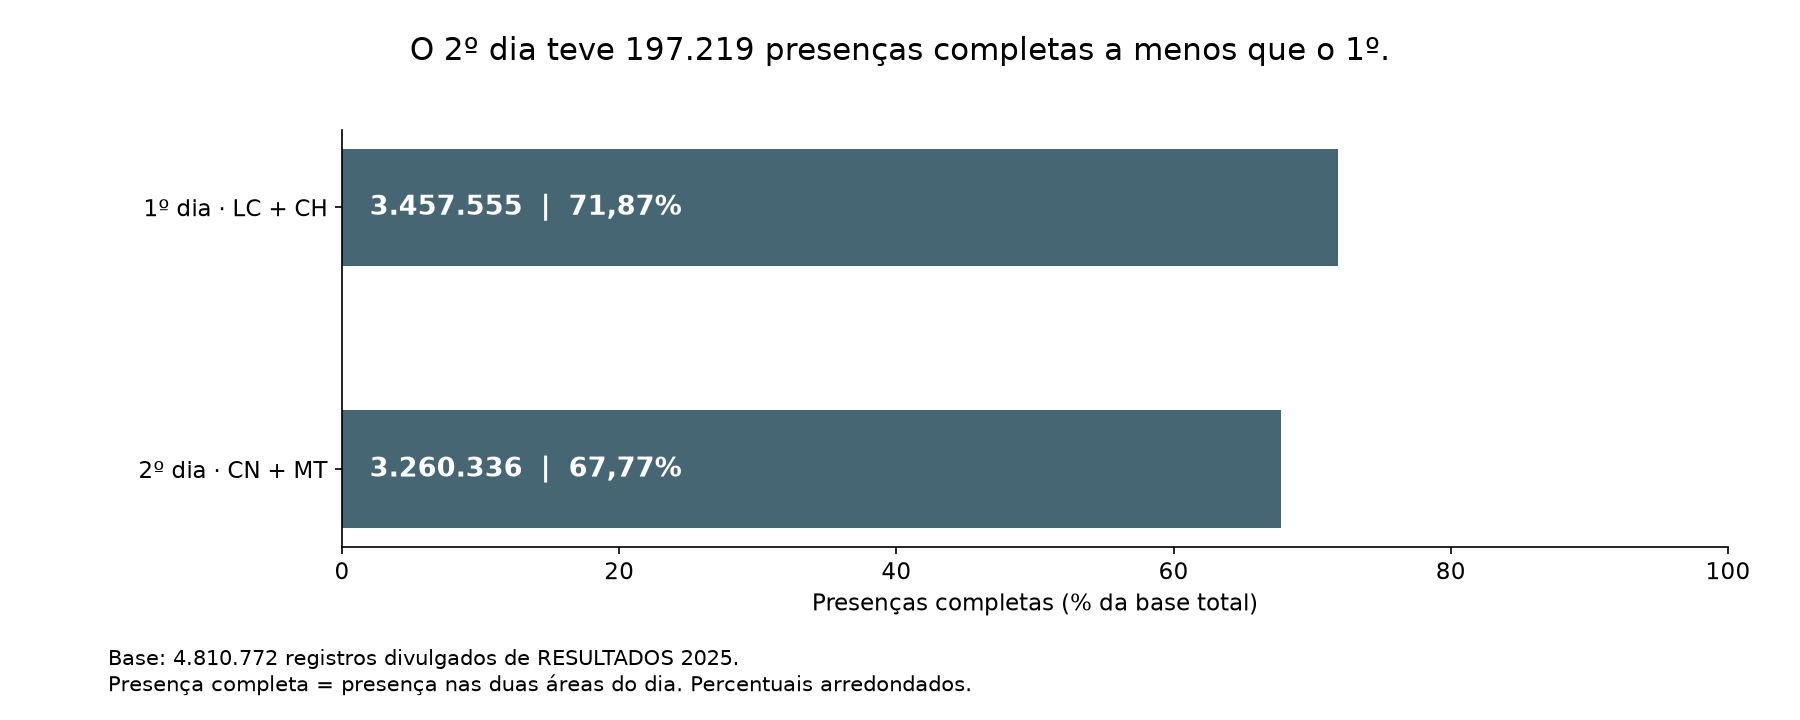

In [2]:
display(Image(filename=str(figuras_participacao[0])))

## Quem continuou presente de um dia para o outro?

**93,83% de quem teve presença completa no 1º dia também esteve presente no 2º dia.**

São **3.244.348** registros com presença completa nos dois dias. O denominador dessa retenção é **3.457.555 presentes completos no 1º dia**, não a base total.

O fluxo acompanha os mesmos registros. O destaque laranja mostra a mudança de presença completa para ausência completa; os demais caminhos ficam em cinza.

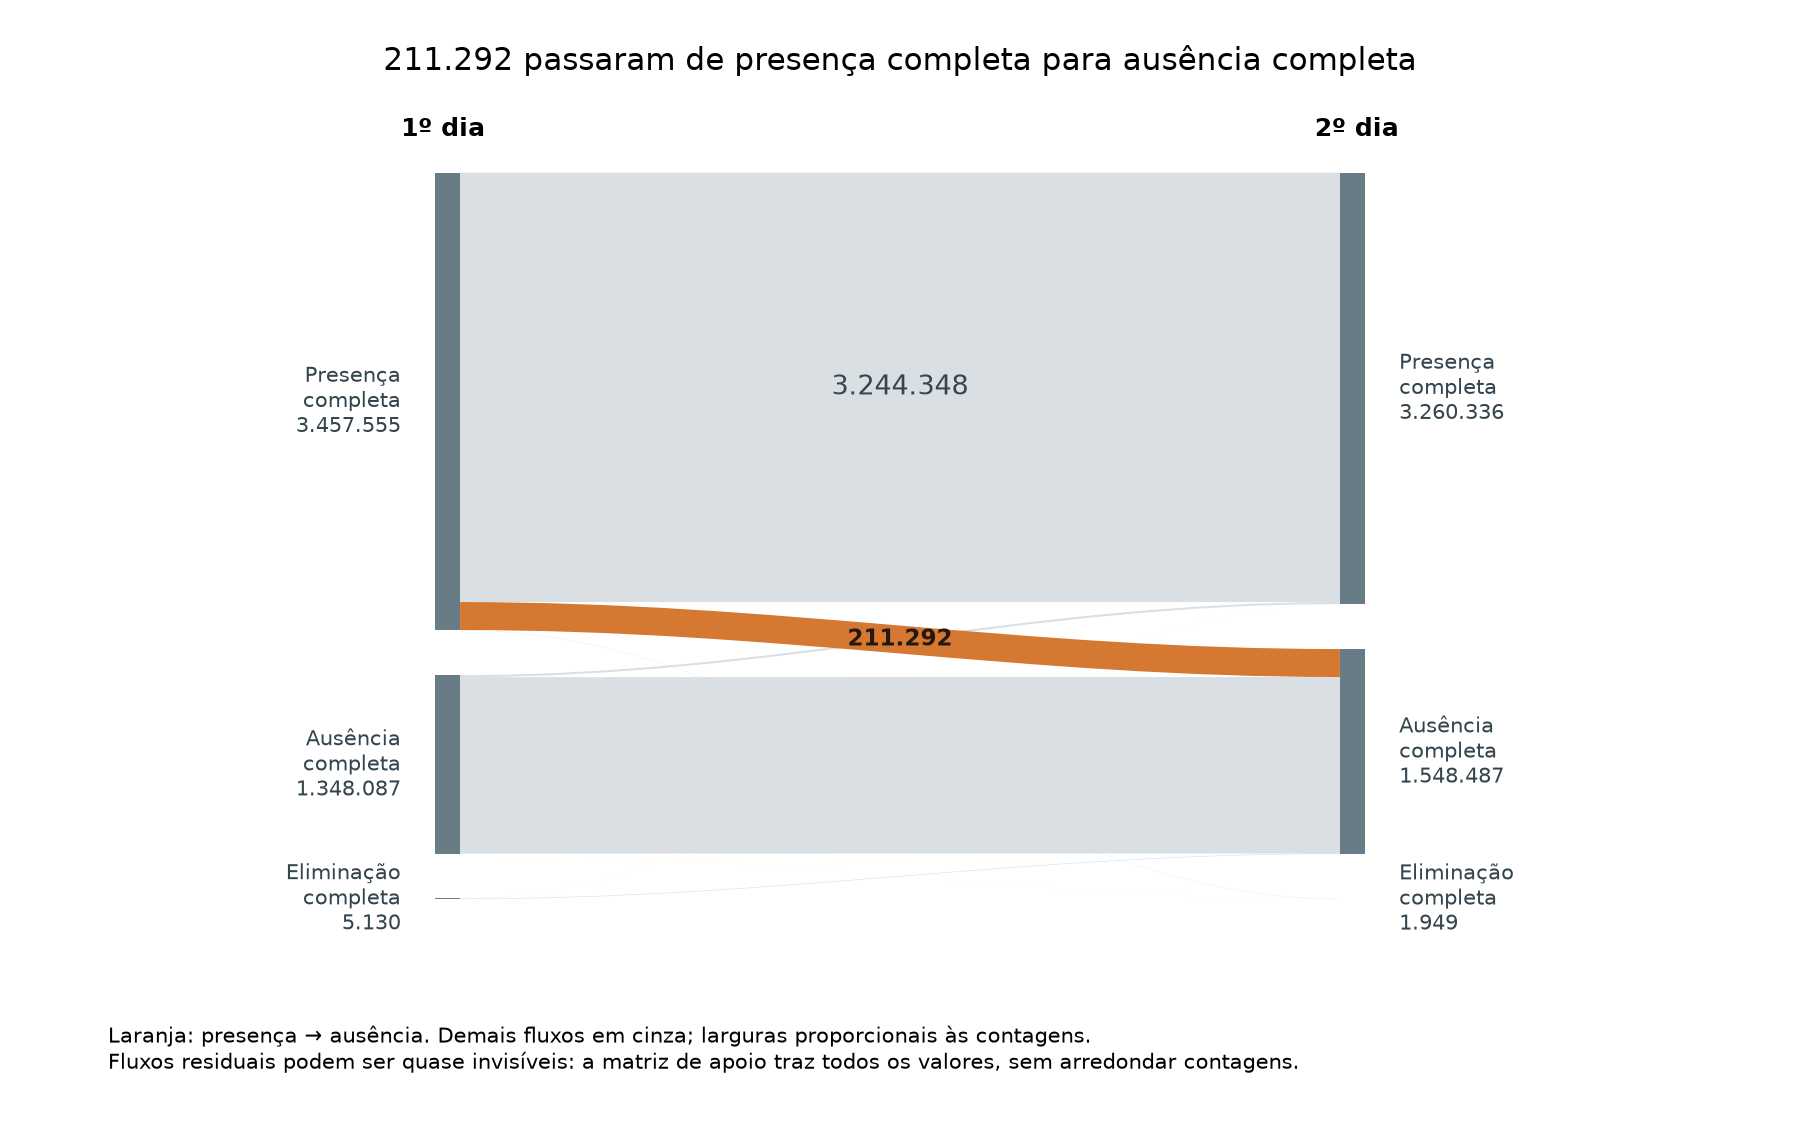

In [3]:
display(Image(filename=str(figuras_participacao[1])))

### Matriz de apoio: nenhum caminho fica de fora

Linhas representam o 1º dia; colunas, o 2º. Cada célula mostra **contagem | % da base total de 4.810.772 registros**. Percentuais positivos menores que 0,01% aparecem como `<0,01%`, não como zero. Situações mistas, dados ausentes e códigos inválidos tiveram zero ocorrência em ambos os dias.

In [4]:
estados = ["presente", "ausente", "eliminado"]
celulas = {(x["dia1"], x["dia2"]): x for x in participacao["transicoes"]}
matriz = pd.DataFrame(
    [[f"{numero(celulas[a, b]['quantidade'])} | {porcentagem(celulas[a, b]['percentual_base'])}" for b in estados] for a in estados],
    index=[NOMES[a] for a in estados], columns=[NOMES[b] for b in estados])
matriz.index.name = "1º dia → 2º dia"
display(matriz)

,Presença completa,Ausência completa,Eliminação completa
1º dia → 2º dia,,,
Presença completa,"3.244.348 | 67,44%","211.292 | 4,39%","1.915 | 0,04%"
Ausência completa,"15.146 | 0,31%","1.332.913 | 27,71%","28 | <0,01%"
Eliminação completa,"842 | 0,02%","4.282 | 0,09%","6 | <0,01%"


## Menos presença no total não significa a mesma quantidade de faltas

**211.292** registros passaram de presença completa para ausência completa. Outros **15.146** fizeram o caminho inverso. E houve mudanças envolvendo eliminação: **1.915** passaram de presença completa para eliminação completa; **842**, de eliminação completa para presença completa.

Por isso, a queda líquida de **197.219** presenças é diferente dos 211.292 que passaram de presente a ausente. A conta fecha assim: **15.146 + 842 − 211.292 − 1.915 = −197.219**. Isso descreve mudanças registradas, sem explicar suas causas.

## Agora, as notas de quem participou

**Agora que entendemos quem chegou a cada dia, analisamos as notas de quem efetivamente participou.**

Cada área inclui somente presentes com nota disponível naquela área, sem exigir presença nas outras áreas. **Zero é mantido.** São 3.260.336 notas elegíveis por área em Natureza e Matemática e 3.457.555 por área em Humanas e Linguagens.

## O centro e a dispersão contam partes diferentes da história

O ponto marca a mediana; a faixa colorida reúne os 50% centrais das notas (Q1–Q3). Em Matemática, essa faixa vai de 416,5 a 606,8, com mediana 500,0 e média 519,98. Esses números descrevem esta população, sem estabelecer dificuldade relativa entre áreas.

A linha fina vai do mínimo ao máximo **observados**, não aos limites teóricos possíveis da prova.

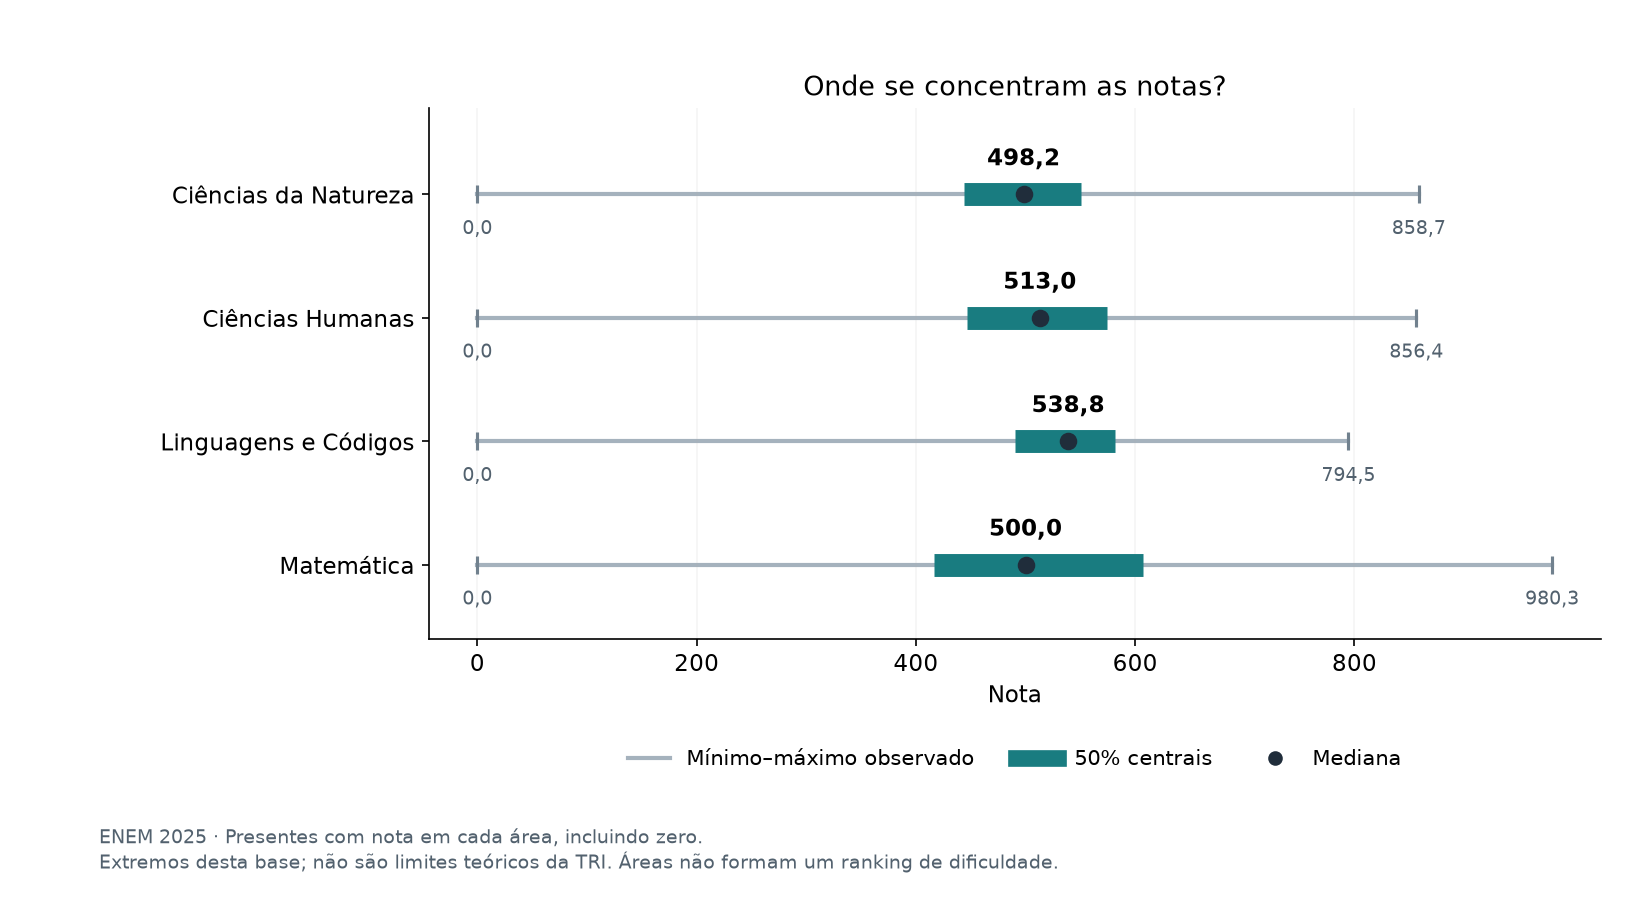

In [5]:
display(Image(filename=str(raiz / "apresentacao/graficos/quartis_por_area_2025.png")))

In [6]:
colunas = {"nome_area":"Área", "elegiveis":"Notas analisadas", "minimo_observado":"Mínimo observado", "q1":"Q1", "mediana":"Mediana", "q3":"Q3", "maximo_observado":"Máximo observado", "media":"Média"}
display(tabela[list(colunas)].rename(columns=colunas).round(2))

,Área,Notas analisadas,Mínimo observado,Q1,Mediana,Q3,Máximo observado,Média
0,Ciências da Natureza,3260336,0.0,443.5,498.2,550.9,858.7,499.97
1,Ciências Humanas,3457555,0.0,446.6,513.0,574.0,856.4,511.19
2,Linguagens e Códigos,3457555,0.0,490.3,538.8,581.6,794.5,532.12
3,Matemática,3260336,0.0,416.5,500.0,606.8,980.3,519.98


## Observado não significa limite teórico

Há notas zero nesta base e elas foram preservadas. Os máximos observados são 858,7 em Natureza, 856,4 em Humanas, 794,5 em Linguagens e 980,3 em Matemática. Isso não estabelece os limites possíveis das provas nem explica a origem de cada zero.

A TRI não tem uma escala universal fixa de 0 a 1000; os limites de uma prova dependem dos itens. Não estimamos esses limites neste trabalho. [Referência: guia do Inep](https://www.gov.br/inep/pt-br/centrais-de-conteudo/acervo-linha-editorial/publicacoes-institucionais/avaliacoes-e-exames-da-educacao-basica/entenda-a-sua-nota-no-enem-guia-do-participante).

## O que podemos dizer — e o que ainda não sabemos

Acompanhamos registros divulgados de RESULTADOS 2025, não todos os inscritos do país. A comparação não informa motivos de ausência nem demonstra evasão causal. Presença nas áreas não é uma medição de horários ou sessões. Dados mistos, ausentes ou inválidos seriam mantidos e sinalizados, sem correção automática.

**Próximas perguntas:** presença e notas por região de aplicação, após ampliar a trusted e definir taxa versus volume; desempenho por rede; redação; e perfil econômico independente. Local de prova não é residência. Renda continua sem vínculo individual com notas em 2025. Esses próximos recortes ainda não foram executados.

Os contratos ficam em `docs/`, os CSV em `analitica/` e as auditorias em `reports/`.